# 5511 - Module 5  - I am a Painter

## Setup Environment - tensorflow backend, Keras library and optimise for MacOS

In [18]:
import os
import sys
import glob
import time
import io
from pathlib import Path
from datetime import datetime
import warnings
import numpy as np
import random
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

import platform
import gc
import zipfile

os.environ['KERAS_BACKEND'] = 'tensorflow'
import tensorflow as tf
from tensorflow.keras import mixed_precision

autotune = tf.data.AUTOTUNE

import keras
from keras import layers, ops
import tensorflow_datasets as tfds

# Determine if we're running locally or in Kaggle'
KAGGLE_ENV = os.path.exists('/kaggle/input')
if KAGGLE_ENV:
    print("Using Kaggle competition data")
    DATA_DIR = Path('/kaggle/input/gan-getting-started')
else:
    print("Running locally with downloaded Kaggle data")
    DATA_DIR = Path("data/gan-getting-started")

    # Set up for Apple Silicon GPU acceleration - locally I run a MacBook Pro M1
    is_macos = platform.system() == "Darwin"
    if is_macos:
        print(f"Running on macOS: {is_macos}")

        USE_MIXED_PRECISION = False  # Not always a good idea, so use variable to turn on/off

        # Enable GPU acceleration if available
        print("Metal GPU Available: ", len(tf.config.list_physical_devices('GPU')) > 0)
        if tf.config.list_physical_devices('GPU'):
            print("Using GPU acceleration with Metal")
            for gpu in tf.config.list_physical_devices('GPU'):
                tf.config.experimental.set_memory_growth(gpu, True)
        else:
            print("GPU not available, using CPU")
        # Enable mixed precision policy
        if USE_MIXED_PRECISION:
            policy = mixed_precision.Policy('mixed_float16')
        else:
            policy = mixed_precision.Policy('float32')
        mixed_precision.set_global_policy(policy)
        print(f"Mixed precision policy set to: {policy}")

# paths
OUTPUT_DIR = Path("./outputs/5511_module5")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR = Path("./figs/5511_module5")
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR = Path("./models/5511_module5")
MODEL_DIR.mkdir(exist_ok=True, parents=True)
# input image files (to work locally or on Kaggle)
monet_jpg_dir = DATA_DIR / "monet_jpg"
monet_tfrec_dir = DATA_DIR / "monet_tfrec"
photo_jpg_dir = DATA_DIR / "photo_jpg"
photo_tfrec_dir = DATA_DIR / "photo_tfrec"
# Output directory for generated images
generated_images_dir = OUTPUT_DIR / "generated_monets"
generated_images_dir.mkdir(exist_ok=True, parents=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

# Helper function added as I suspect I am going to encounter some issues with memory usage.
def print_memory_usage(label=""):
    available = psutil.virtual_memory().available / (1024**3)
    used = psutil.virtual_memory().used / (1024**3)
    print(f"{label} - Available: {available:.1f}GB, Used: {used:.1f}GB")

Running locally with downloaded Kaggle data
Running on macOS: True
Metal GPU Available:  True
Using GPU acceleration with Metal
Mixed precision policy set to: <DTypePolicy "float32">
Python: 3.11.13
TensorFlow version: 2.19.1
Keras version: 3.11.3


In [2]:
# Set up some initial parameters
orig_img_size = (256, 256)
# Size of the random crops to be used during training.
input_img_size = (256, 256, 3)
# Weights initializer for the layers.
kernel_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)
# Gamma initializer for instance normalization.
gamma_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)

buffer_size = 256
batch_size = 1

## 1) Problem Description

This project will generate images in the style of Monet. By using machine learning techniques, we can identify the different styles such as color pallete or brush strokes of different artists. This involved using 2 neural networks: a generator model and a discriminator model. The generator will create the images in the style of Monet. The discriminator will try to accurately classify the real vs generated images. We are tasked to build a GAN to generate thousands of Monet style images.
We are given 300 monet paintings and 7038 photos of size 256x256. https://www.kaggle.com/competitions/gan-getting-started

This is my first attempt to do anything with a GAN, I made heavy use of the Keras CycleGAN implementation available here: https://keras.io/examples/generative/cyclegan/
Given the very lengthy and troublesome experience buidling CNNs, my focus here is learning from a successful implementation, adapting it to the project requirements and learning more about how I can implement such models moving forwards.

## 2) Prepare the Dataset

Notes on data preparation decisions:

1) We have 7028 photos, but only 300 Monets, so we will need to use 100% of the data for training. As this is unsupervised learning, it is not an issue to not holdout validation/test sets. Instead, I will use sampling to provide a smaller dataset for monitoring the results.
2) I have used repeat() to make it go on indefinitely and if desired use all the available training photos with randomly selected Monets from the 300. This means that I must remember to use epochs= xx and steps per epoch= yy for it to work.
3) I have limited augmentation to random flipping and resizing.
4) I have used tfrec to load the data. I believe it offers large performance enhancements during training over loading from the jpegs.
5) The train_dataset is pre-zipped, which I hope will make life simpler as I progress.

The last step is to print some basic stats about the train_dataset created and check a few sample images, just to make sure everything is working as expected.

In [3]:
def create_cyclegan_dataset(photo_files, monet_files, img_size=(256, 256), batch_size=batch_size):
    """Optimized dataset for CycleGAN training"""

    if not monet_files or not photo_files:
        raise ValueError("Both monet_files and photo_files must be non-empty lists")

    print(f"Creating dataset with {len(monet_files)} Monet files and {len(photo_files)} photo files")

    def parse_and_resize(record):
        example = tf.io.parse_single_example(record, {
            'image': tf.io.FixedLenFeature([], tf.string)
        })
        image = tf.io.decode_jpeg(example['image'], channels=3)
        image = tf.image.resize(image, img_size)
        image = tf.image.random_flip_left_right(image)
        image = tf.cast(image, tf.float32) / 127.5 - 1.0  # Normalize to [-1, 1]
        return image

    monet_ds = (tf.data.TFRecordDataset(monet_files, num_parallel_reads=tf.data.AUTOTUNE)
                .map(parse_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
                .shuffle(1000)
                .repeat()
                .batch(batch_size)  # Made this configurable
                .prefetch(tf.data.AUTOTUNE))

    photo_ds = (tf.data.TFRecordDataset(photo_files, num_parallel_reads=tf.data.AUTOTUNE)
                .map(parse_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
                .shuffle(1000)
                .repeat()
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

    # Add prefetch to the final zipped dataset
    return tf.data.Dataset.zip((photo_ds, monet_ds)).prefetch(tf.data.AUTOTUNE)

# Load TFRecord datasets
monet_files = tf.io.gfile.glob(f"{monet_tfrec_dir}/*.tfrec")
photo_files = tf.io.gfile.glob(f"{photo_tfrec_dir}/*.tfrec")

# given only 300 Monet images, use all data for training
train_dataset = create_cyclegan_dataset(monet_files, photo_files)

# For monitoring, just take a few batches from the training data
monitor_dataset = train_dataset.take(5)  # Take first 5 batches for visualization


Creating dataset with 20 Monet files and 5 photo files


2025-10-10 19:35:25.076121: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-10-10 19:35:25.076167: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-10-10 19:35:25.076173: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1760121325.076369 8963403 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1760121325.076559 8963403 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


=== Dataset Summary ===


2025-10-10 19:35:25.293197: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144


Monet batch shape: (1, 256, 256, 3)
Photo batch shape: (1, 256, 256, 3)
Monet batch dtype: <dtype: 'float32'>
Photo batch dtype: <dtype: 'float32'>

Value ranges:
Monet batch - min: -1.000, max: 0.992
Photo batch - min: -1.000, max: 1.000

Counting total batches...


2025-10-10 19:35:25.903585: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


First 100 batches counted (dataset uses .repeat() so it's infinite)

Approximate memory per batch: 1.50 MB

Visualising some samples...


2025-10-10 19:35:26.233906: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


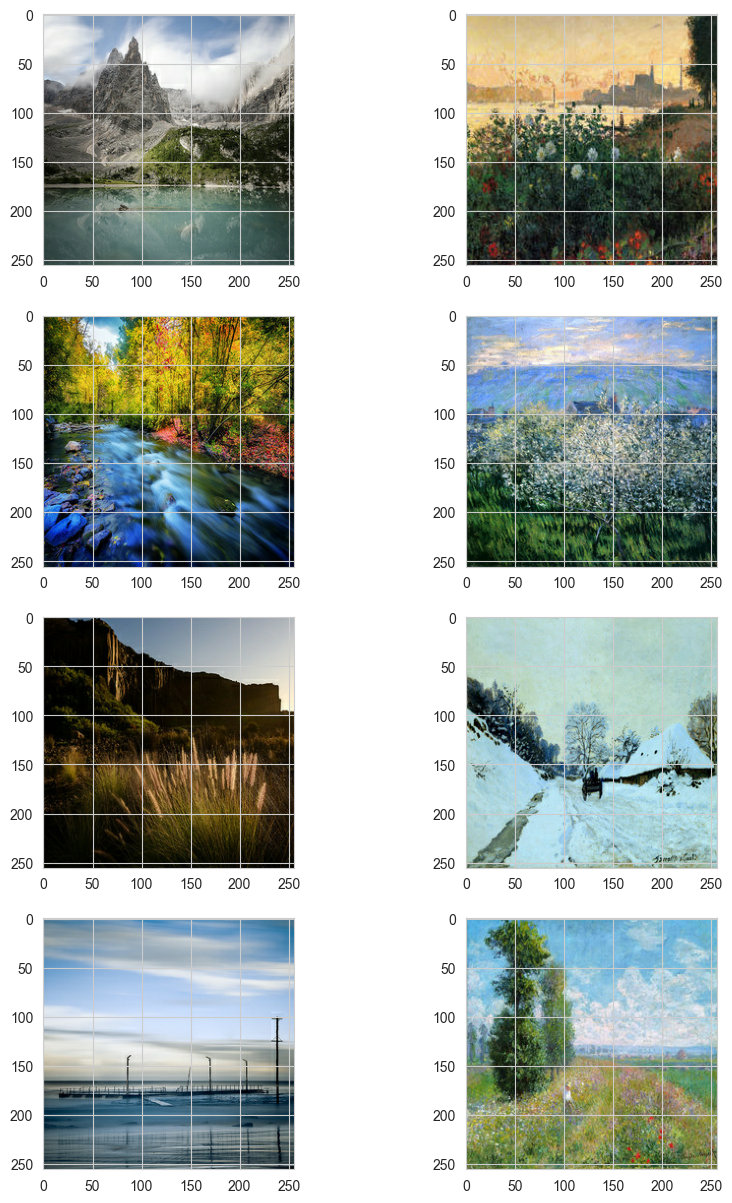

In [4]:
# Basic dataset info
print("=== Dataset Summary ===")

# 1. Check a single batch to understand the structure
sample_batch = next(iter(train_dataset))
monet_batch, photo_batch = sample_batch
print(f"Monet batch shape: {monet_batch.shape}")
print(f"Photo batch shape: {photo_batch.shape}")
print(f"Monet batch dtype: {monet_batch.dtype}")
print(f"Photo batch dtype: {photo_batch.dtype}")

# 2. Check value ranges (should be [-1, 1] after normalization)
print(f"\nValue ranges:")
print(f"Monet batch - min: {tf.reduce_min(monet_batch):.3f}, max: {tf.reduce_max(monet_batch):.3f}")
print(f"Photo batch - min: {tf.reduce_min(photo_batch):.3f}, max: {tf.reduce_max(photo_batch):.3f}")

# 3. Estimate total number of batches (this will consume the dataset, so recreate after)
print(f"\nCounting total batches...")
batch_count = 0
for batch in train_dataset.take(100):  # Take first 100 to avoid infinite loop
    batch_count += 1
print(f"First 100 batches counted (dataset uses .repeat() so it's infinite)")

# 4. Memory usage per batch (approximate)
batch_size_bytes = monet_batch.numpy().nbytes + photo_batch.numpy().nbytes
print(f"\nApproximate memory per batch: {batch_size_bytes / (1024**2):.2f} MB")

# 5. Visualise some samples
print(f"\nVisualising some samples...")
_, ax = plt.subplots(4, 2, figsize=(10, 15))
for i, samples in enumerate(train_dataset.take(4)):
    monet = (((samples[0][0] * 127.5) + 127.5).numpy()).astype(np.uint8)
    photo = (((samples[1][0] * 127.5) + 127.5).numpy()).astype(np.uint8)
    ax[i, 0].imshow(photo)
    ax[i, 1].imshow(monet)
plt.show()

## Building blocks used in the CycleGAN generators and discriminators

In [5]:
class ReflectionPadding2D(layers.Layer):
    """Implements Reflection Padding as a layer.

    Args:
        padding(tuple): Amount of padding for the
        spatial dimensions.

    Returns:
        A padded tensor with the same type as the input tensor.
    """

    def __init__(self, padding=(1, 1), **kwargs):
        self.padding = tuple(padding)
        super().__init__(**kwargs)

    def call(self, input_tensor, mask=None):
        padding_width, padding_height = self.padding
        padding_tensor = [
            [0, 0],
            [padding_height, padding_height],
            [padding_width, padding_width],
            [0, 0],
        ]
        return ops.pad(input_tensor, padding_tensor, mode="REFLECT")


def residual_block(
    x,
    activation,
    kernel_initializer=kernel_init,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="valid",
    gamma_initializer=gamma_init,
    use_bias=False,
):
    dim = x.shape[-1]
    input_tensor = x

    x = ReflectionPadding2D()(input_tensor)
    x = layers.Conv2D(
        dim,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    x = activation(x)

    x = ReflectionPadding2D()(x)
    x = layers.Conv2D(
        dim,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    x = layers.add([input_tensor, x])
    return x


def downsample(
    x,
    filters,
    activation,
    kernel_initializer=kernel_init,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding="same",
    gamma_initializer=gamma_init,
    use_bias=False,
):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        kernel_initializer=kernel_initializer,
        padding=padding,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    if activation:
        x = activation(x)
    return x


def upsample(
    x,
    filters,
    activation,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding="same",
    kernel_initializer=kernel_init,
    gamma_initializer=gamma_init,
    use_bias=False,
):
    x = layers.Conv2DTranspose(
        filters,
        kernel_size,
        strides=strides,
        padding=padding,
        kernel_initializer=kernel_initializer,
        use_bias=use_bias,
    )(x)
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    if activation:
        x = activation(x)
    return x

## Build the Generators

The generator consists of downsampling blocks: nine residual blocks and upsampling blocks. The structure of the generator is the following:

1) Front-end / encoder (downsample)
- ReflectionPad2D (avoid edge artifacts)
- Conv7×7, stride 1, GroupNorm, ReLU  (GroupNorm stabilizes training)
- downsample (Conv3×3, stride 2 (×2 times) → feature maps double each step (e.g., 64→128→256)) x 2
2) Core / transformer (residual blocks) x 9
- Conv3×3 → GroupNorm → ReLU → Residual add.
- These learn the “style/appearance” change without destroying content/structure.
3) Back-end / decoder (upsample)
- UpSampling2D = Conv2DTranspose, GroupNorm, ReLU x 2
- Final Conv7×7, tanh to output in [−1,1]


In [6]:
def get_resnet_generator(
    filters=64,
    num_downsampling_blocks=2,
    num_residual_blocks=9,
    num_upsample_blocks=2,
    gamma_initializer=gamma_init,
    name=None,
):
    img_input = layers.Input(shape=input_img_size, name=name + "_img_input")
    x = ReflectionPadding2D(padding=(3, 3))(img_input)
    x = layers.Conv2D(filters, (7, 7), kernel_initializer=kernel_init, use_bias=False)(
        x
    )
    x = keras.layers.GroupNormalization(groups=1, gamma_initializer=gamma_initializer)(
        x
    )
    x = layers.Activation("relu")(x)

    # Downsampling
    for _ in range(num_downsampling_blocks):
        filters *= 2
        x = downsample(x, filters=filters, activation=layers.Activation("relu"))

    # Residual blocks
    for _ in range(num_residual_blocks):
        x = residual_block(x, activation=layers.Activation("relu"))

    # Upsampling
    for _ in range(num_upsample_blocks):
        filters //= 2
        x = upsample(x, filters, activation=layers.Activation("relu"))

    # Final block
    x = ReflectionPadding2D(padding=(3, 3))(x)
    x = layers.Conv2D(3, (7, 7), padding="valid")(x)
    x = layers.Activation("tanh")(x)

    model = keras.models.Model(img_input, x, name=name)
    return model


## Build the Discriminators

The discriminators implement the following architecture:
`C64->C128->C256->C512`

In [7]:
def get_discriminator(
    filters=64, kernel_initializer=kernel_init, num_downsampling=3, name=None
):
    img_input = layers.Input(shape=input_img_size, name=name + "_img_input")
    x = layers.Conv2D(
        filters,
        (4, 4),
        strides=(2, 2),
        padding="same",
        kernel_initializer=kernel_initializer,
    )(img_input)
    x = layers.LeakyReLU(0.2)(x)

    num_filters = filters
    for num_downsample_block in range(3):
        num_filters *= 2
        if num_downsample_block < 2:
            x = downsample(
                x,
                filters=num_filters,
                activation=layers.LeakyReLU(0.2),
                kernel_size=(4, 4),
                strides=(2, 2),
            )
        else:
            x = downsample(
                x,
                filters=num_filters,
                activation=layers.LeakyReLU(0.2),
                kernel_size=(4, 4),
                strides=(1, 1),
            )

    x = layers.Conv2D(
        1, (4, 4), strides=(1, 1), padding="same", kernel_initializer=kernel_initializer
    )(x)

    model = keras.models.Model(inputs=img_input, outputs=x, name=name)
    return model

In [8]:
# Get the generators
gen_G = get_resnet_generator(name="generator_G")
gen_F = get_resnet_generator(name="generator_F")

# Get the discriminators
disc_X = get_discriminator(name="discriminator_X")
disc_Y = get_discriminator(name="discriminator_Y")

## Build the CycleGAN model

### CycleGAN Loss Functions

In CycleGAN, there are **two GANs working in opposite directions** (X → Y and Y → X).

#### 1. Adversarial Loss
For mapping **X → Y** with generator $G$ and discriminator $D_Y$:

$$
L_{GAN}(G, D_Y, X, Y) = \mathbb{E}_{y \sim p_{data}(Y)}[\log D_Y(y)]
+ \mathbb{E}_{x \sim p_{data}(X)}[\log(1 - D_Y(G(x)))]
$$

Similarly, for **Y → X** with generator $F$ and discriminator $D_X$:

$$
L_{GAN}(F, D_X, Y, X) = \mathbb{E}_{x \sim p_{data}(X)}[\log D_X(x)]
+ \mathbb{E}_{y \sim p_{data}(Y)}[\log(1 - D_X(F(y)))]
$$

#### 2. Cycle Consistency Loss
Ensures that translating there and back gives the original image:

$$
L_{cyc}(G, F) = \mathbb{E}_{x \sim p_{data}(X)}[\|F(G(x)) - x\|_1]
+ \mathbb{E}_{y \sim p_{data}(Y)}[\|G(F(y)) - y\|_1]
$$

#### 3. Identity Loss (optional)
Helps preserve colors/structure when inputs already belong to the target domain:

$$
L_{identity}(G, F) = \mathbb{E}_{y \sim p_{data}(Y)}[\|G(y) - y\|_1]
+ \mathbb{E}_{x \sim p_{data}(X)}[\|F(x) - x\|_1]
$$

#### 4. Full Objective
The total CycleGAN loss combines all components:

$$
L(G, F, D_X, D_Y) = L_{GAN}(G, D_Y, X, Y)
+ L_{GAN}(F, D_X, Y, X)
+ \lambda \, L_{cyc}(G, F)
+ \gamma \, L_{identity}(G, F)
$$

Where:
- $\lambda$ controls the importance of **cycle consistency** (usually large, e.g., 10).
- $\gamma$ controls the weight of the **identity loss** (often smaller or optional).

### Implementation in class CycleGan below:
In each training step where x = photo, y = Monet
- photo to fake Monet -> x2y
- Monet to fake photo -> y2x
- Cycle (Photo to fake Monet to fake photo): x -> y -> x
- Cycle (Monet to fake photo to fake Monet) y -> x -> y
- Identity mapping  (x from real_x and y from real_y)
- Discriminator X output for x
- Discriminator Y output for y
- Generator adversarial loss (G = discriminator on fake y)
- Generator adversarial loss (F = discriminator on fake x)
- Generator cycle loss  (G = monet to photo to monet, F = photo to Monet to photo)
- Generator identity loss  (G = real y to y, F = real x to x)
So:
- total_loss_G = gen_G_loss + cycle_loss_G + id_loss_G
- total_loss_F = gen_F_loss + cycle_loss_F + id_loss_F

then:
- calc discriminator loss
- get generator gradients
- get discriminator gradients
- update weights (generators and discriminators)

In [9]:
@keras.saving.register_keras_serializable()
class CycleGan(keras.Model):
    def __init__(
        self,
        generator_G,
        generator_F,
        discriminator_X,
        discriminator_Y,
        lambda_cycle=10.0,
        lambda_identity=0.5,
    ):
        super().__init__()
        self.gen_G = generator_G
        self.gen_F = generator_F
        self.disc_X = discriminator_X
        self.disc_Y = discriminator_Y
        self.lambda_cycle = lambda_cycle
        self.lambda_identity = lambda_identity

    def call(self, inputs):
        return (
            self.disc_X(inputs),
            self.disc_Y(inputs),
            self.gen_G(inputs),
            self.gen_F(inputs),
        )

    def compile(
        self,
        gen_G_optimizer,
        gen_F_optimizer,
        disc_X_optimizer,
        disc_Y_optimizer,
        gen_loss_fn,
        disc_loss_fn,
        **kwargs,
    ):
        super().compile(**kwargs)
        self.gen_G_optimizer = gen_G_optimizer
        self.gen_F_optimizer = gen_F_optimizer
        self.disc_X_optimizer = disc_X_optimizer
        self.disc_Y_optimizer = disc_Y_optimizer
        self.generator_loss_fn = gen_loss_fn
        self.discriminator_loss_fn = disc_loss_fn
        self.cycle_loss_fn = keras.losses.MeanAbsoluteError()
        self.identity_loss_fn = keras.losses.MeanAbsoluteError()

    def train_step(self, batch_data):
        # x is photo and y is Monet
        real_x, real_y = batch_data

        # For CycleGAN, we need to calculate different
        # kinds of losses for the generators and discriminators.
        # We will perform the following steps here:
        #
        # 1. Pass real images through the generators and get the generated images
        # 2. Pass the generated images back to the generators to check if we
        #    can predict the original image from the generated image.
        # 3. Do an identity mapping of the real images using the generators.
        # 4. Pass the generated images in 1) to the corresponding discriminators.
        # 5. Calculate the generators total loss (adversarial + cycle + identity)
        # 6. Calculate the discriminators loss
        # 7. Update the weights of the generators
        # 8. Update the weights of the discriminators
        # 9. Return the losses in a dictionary

        with tf.GradientTape(persistent=True) as tape:
            # photo to fake Monet -> x2y
            fake_y = self.gen_G(real_x, training=True)
            # Monet to fake photo -> y2x
            fake_x = self.gen_F(real_y, training=True)

            # Cycle (Photo to fake Monet to fake photo): x -> y -> x
            cycled_x = self.gen_F(fake_y, training=True)
            # Cycle (Monet to fake photo to fake Monet) y -> x -> y
            cycled_y = self.gen_G(fake_x, training=True)

            # Identity mapping
            same_x = self.gen_F(real_x, training=True)
            same_y = self.gen_G(real_y, training=True)

            # Discriminator output
            disc_real_x = self.disc_X(real_x, training=True)
            disc_fake_x = self.disc_X(fake_x, training=True)

            disc_real_y = self.disc_Y(real_y, training=True)
            disc_fake_y = self.disc_Y(fake_y, training=True)

            # Generator adversarial loss
            gen_G_loss = self.generator_loss_fn(disc_fake_y)
            gen_F_loss = self.generator_loss_fn(disc_fake_x)

            # Generator cycle loss
            cycle_loss_G = self.cycle_loss_fn(real_y, cycled_y) * self.lambda_cycle
            cycle_loss_F = self.cycle_loss_fn(real_x, cycled_x) * self.lambda_cycle

            # Generator identity loss
            id_loss_G = (
                self.identity_loss_fn(real_y, same_y)
                * self.lambda_cycle
                * self.lambda_identity
            )
            id_loss_F = (
                self.identity_loss_fn(real_x, same_x)
                * self.lambda_cycle
                * self.lambda_identity
            )

            # Total generator loss
            total_loss_G = gen_G_loss + cycle_loss_G + id_loss_G
            total_loss_F = gen_F_loss + cycle_loss_F + id_loss_F

            # Discriminator loss
            disc_X_loss = self.discriminator_loss_fn(disc_real_x, disc_fake_x)
            disc_Y_loss = self.discriminator_loss_fn(disc_real_y, disc_fake_y)

        # Get the gradients for the generators
        grads_G = tape.gradient(total_loss_G, self.gen_G.trainable_variables)
        grads_F = tape.gradient(total_loss_F, self.gen_F.trainable_variables)

        # Get the gradients for the discriminators
        disc_X_grads = tape.gradient(disc_X_loss, self.disc_X.trainable_variables)
        disc_Y_grads = tape.gradient(disc_Y_loss, self.disc_Y.trainable_variables)

        # Update the weights of the generators
        self.gen_G_optimizer.apply_gradients(
            zip(grads_G, self.gen_G.trainable_variables)
        )
        self.gen_F_optimizer.apply_gradients(
            zip(grads_F, self.gen_F.trainable_variables)
        )

        # Update the weights of the discriminators
        self.disc_X_optimizer.apply_gradients(
            zip(disc_X_grads, self.disc_X.trainable_variables)
        )
        self.disc_Y_optimizer.apply_gradients(
            zip(disc_Y_grads, self.disc_Y.trainable_variables)
        )

        return {
            "G_loss": total_loss_G,
            "F_loss": total_loss_F,
            "D_X_loss": disc_X_loss,
            "D_Y_loss": disc_Y_loss,
        }

## Create a callback that periodically saves generated images

In [10]:
class GANMonitor(keras.callbacks.Callback):
    """A callback to generate and save images after each epoch"""

    def __init__(self, num_img=4):
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        _, ax = plt.subplots(4, 2, figsize=(12, 12))
        for i, (monet_img, photo_img) in enumerate(train_dataset.take(self.num_img)):
            prediction = self.model.gen_G(photo_img)[0].numpy()
            prediction = (prediction * 127.5 + 127.5).astype(np.uint8)
            img = (photo_img[0] * 127.5 + 127.5).numpy().astype(np.uint8)

            ax[i, 0].imshow(img)
            ax[i, 1].imshow(prediction)
            ax[i, 0].set_title("Input image")
            ax[i, 1].set_title("Translated image")
            ax[i, 0].axis("off")
            ax[i, 1].axis("off")

            prediction = keras.utils.array_to_img(prediction)
            prediction.save(FIG_DIR / f"generated_img_{i}_{epoch + 1}.png")
        plt.show()
        plt.close()

## Train the end-to-end Model

I have run a couple of test epochs to check things are working. However, each step is taking 1 - 5s.
- With a dataset of 300 Monets to work with, 300 seems an appropriate number of steps per epoch.
- From what I've seen and read so far, I probably need 100+ epochs to get results.
- Total training time locally proved to be **16.5 hours to complete**

I am concerned about this lengthy run, so will run a few checks first. Also, I will reduce number of epochs on Kaggle submission (although the steps should be faster with T4 GPU acceleration).

In [11]:
# Loss function for evaluating adversarial loss
adv_loss_fn = keras.losses.MeanSquaredError()

# Define the loss function for the generators
def generator_loss_fn(fake):
    fake_loss = adv_loss_fn(ops.ones_like(fake), fake)
    return fake_loss


# Define the loss function for the discriminators
def discriminator_loss_fn(real, fake):
    real_loss = adv_loss_fn(ops.ones_like(real), real)
    fake_loss = adv_loss_fn(ops.zeros_like(fake), fake)
    return (real_loss + fake_loss) * 0.5


# Create cycle gan model
cycle_gan_model = CycleGan(
    generator_G=gen_G, generator_F=gen_F, discriminator_X=disc_X, discriminator_Y=disc_Y
)

# Compile the model
cycle_gan_model.compile(
    gen_G_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    gen_F_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    disc_X_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    disc_Y_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    gen_loss_fn=generator_loss_fn,
    disc_loss_fn=discriminator_loss_fn
)

# BUILD the model by calling it on sample data
cycle_gan_model.build([(None, 256, 256, 3), (None, 256, 256, 3)])

# Callbacks
plotter = GANMonitor()
checkpoint_filepath = "./model_checkpoints/cyclegan_checkpoints.weights.h5"
model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, save_weights_only=True
)

class MemoryCleanupCallback(keras.callbacks.Callback):
    def __init__(self, cleanup_freq=5):
        super().__init__()
        self.cleanup_freq = cleanup_freq

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.cleanup_freq == 0:
            gc.collect()
            print(f"Memory cleanup at epoch {epoch + 1}")

callbacks = [
    plotter,
    model_checkpoint_callback,

    keras.callbacks.CSVLogger(
        OUTPUT_DIR / 'training_log.csv', append=True
    ),
    MemoryCleanupCallback(cleanup_freq=10),

]


In [12]:
# Test one training step manually
test_losses = cycle_gan_model.train_step(sample_batch)
print(f"Test losses: {test_losses}")

# Clear any existing GPU memory
if tf.config.list_physical_devices('GPU'):
    tf.keras.backend.clear_session()

# Monitor memory usage
import psutil
print(f"Available RAM: {psutil.virtual_memory().available / (1024**3):.1f} GB")


Test losses: {'G_loss': <tf.Tensor: shape=(), dtype=float32, numpy=7.606261253356934>, 'F_loss': <tf.Tensor: shape=(), dtype=float32, numpy=5.226338863372803>, 'D_X_loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.49982374906539917>, 'D_Y_loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.5009675621986389>}
Available RAM: 13.2 GB


Before training - Available: 13.2GB, Used: 17.1GB


2025-10-10 19:35:41.443433: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - D_X_loss: 0.0957 - D_Y_loss: 0.0427 - F_loss: 5.1081 - G_loss: 5.8375

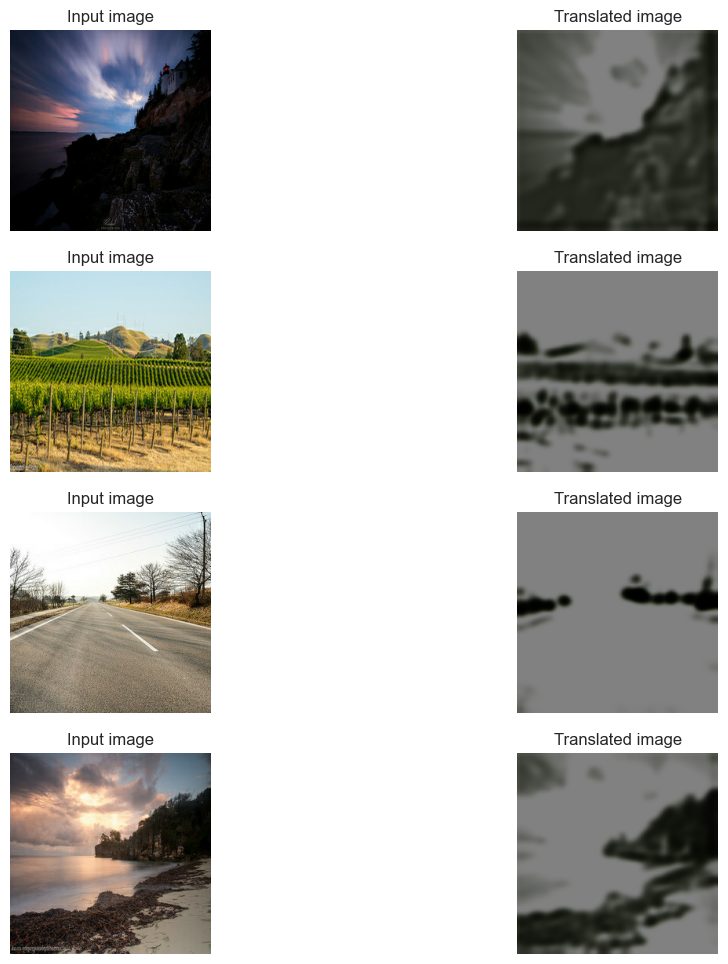

300/300 ━━━━━━━━━━━━━━━━━━━━ 344s 1s/step - D_X_loss: 0.0099 - D_Y_loss: 0.0045 - F_loss: 4.6011 - G_loss: 4.9363
After training - Available: 9.1GB, Used: 13.4GB


In [13]:
# Train the model
print_memory_usage("Before training")

cycle_gan_model.fit(
    train_dataset,
    epochs=1, #set to 2, just to create output that was not too long for notebook submission
    steps_per_epoch=300,  # This is what controls training length
    callbacks=callbacks,
)
print_memory_usage("After training")


## Test the Performance of the Model

In [14]:
def get_next_version_path(base_path, base_name="cyclegan_model"):
    """Find the next available version number for the model"""
    version = 1
    while True:
        filename = f"{base_name}_v{version}.keras"
        full_path = base_path / filename
        if not full_path.exists():
            return full_path
        version += 1

model_path = get_next_version_path(MODEL_DIR)
cycle_gan_model.save(model_path)
print(f"Model saved as: {model_path}")


Model saved as: models/5511_module5/cyclegan_model_v2.keras


#### Note, I disabled the training to generate a Notebook with a reasonable filesize.

However, it was really interesting to see the progression of the model's learning during training. The cell below pulls an example image from every 10th epoch to give some idea how it went...

Loading epochs: [1, 11, 21, 31, 41, 51, 61, 71, 81, 91]


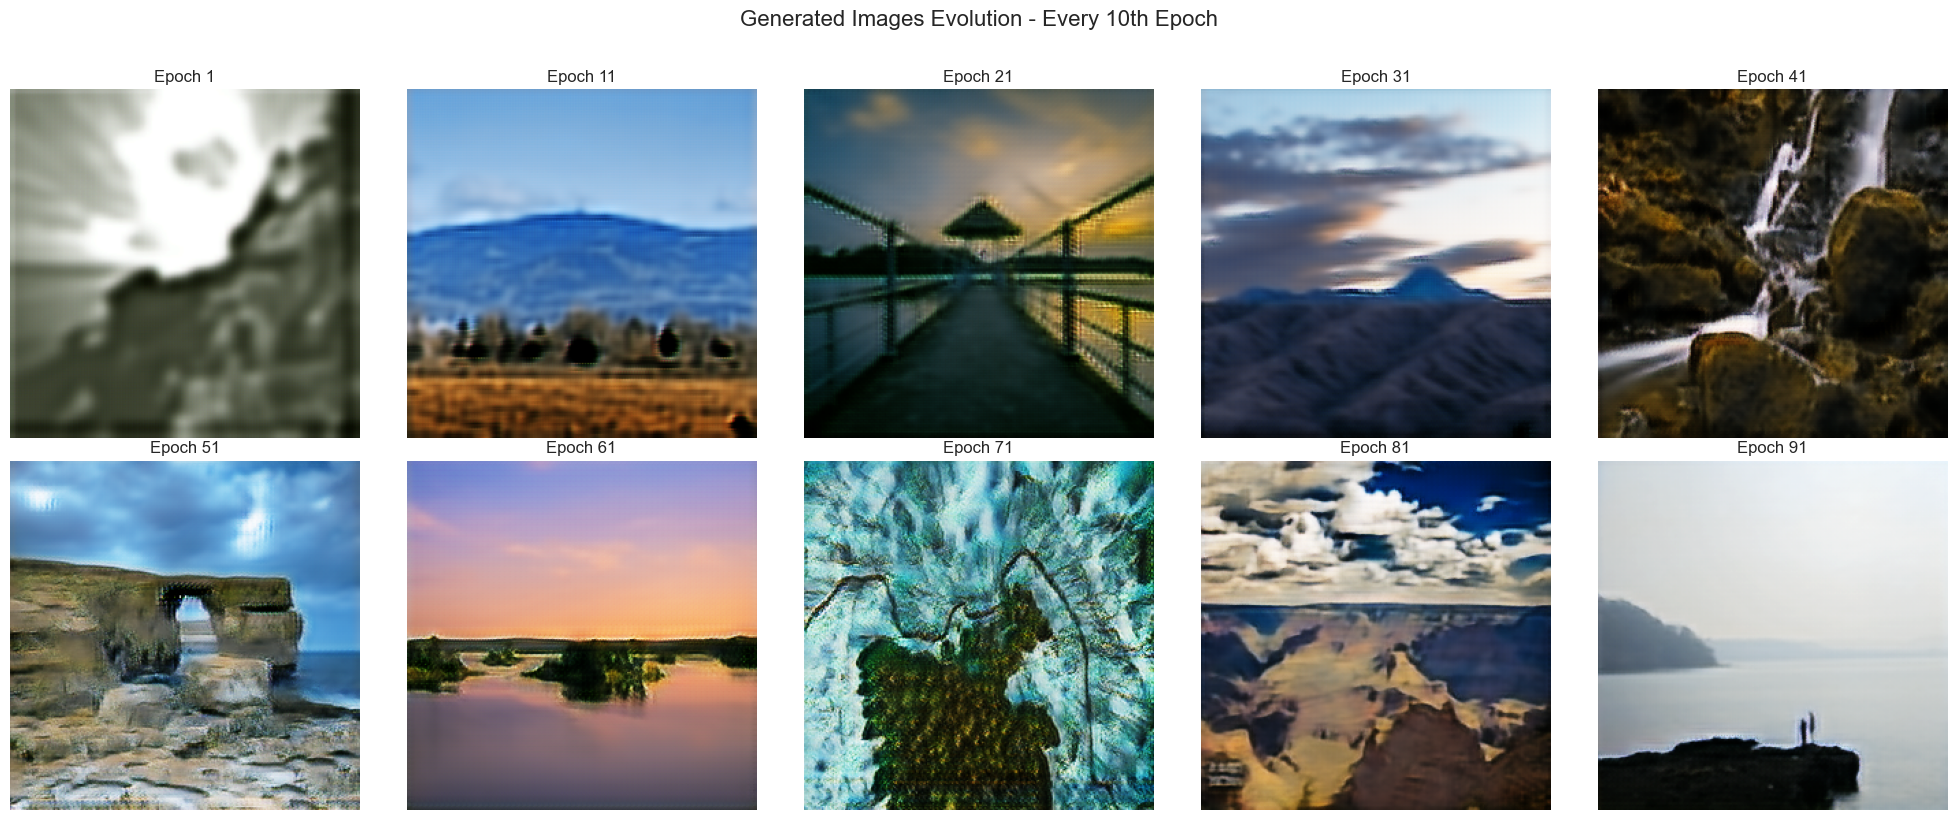

Successfully loaded 10 images


In [15]:
def display_epoch_progression(fig_dir=FIG_DIR, start_epoch=1, step=10, total_images=10):
    from PIL import Image

    # Create list of epoch numbers to load
    epochs_to_load = [start_epoch + i * step for i in range(total_images)]
    print(f"Loading epochs: {epochs_to_load}")

    # Set up the plot - 5x2 grid
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()  # Make it easier to iterate

    loaded_count = 0

    for i, epoch in enumerate(epochs_to_load):
        if i >= total_images:
            break

        # Construct filename - using img_0 since that's what your GANMonitor saves
        filename = f"generated_img_0_{epoch}.png"
        filepath = fig_dir / filename

        try:
            # Load and display the image
            img = Image.open(filepath)
            axes[i].imshow(img)
            axes[i].set_title(f'Epoch {epoch}', fontsize=12)
            axes[i].axis('off')
            loaded_count += 1

        except FileNotFoundError:
            print(f"Warning: File {filename} not found")
            axes[i].text(0.5, 0.5, f'Epoch {epoch}\n(Not Found)',
                         ha='center', va='center', transform=axes[i].transAxes)
            axes[i].axis('off')

    # Hide any unused subplots
    for i in range(loaded_count, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Generated Images Evolution - Every 10th Epoch', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Successfully loaded {loaded_count} images")


# Call the function
display_epoch_progression()

2025-10-10 19:41:20.345966: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


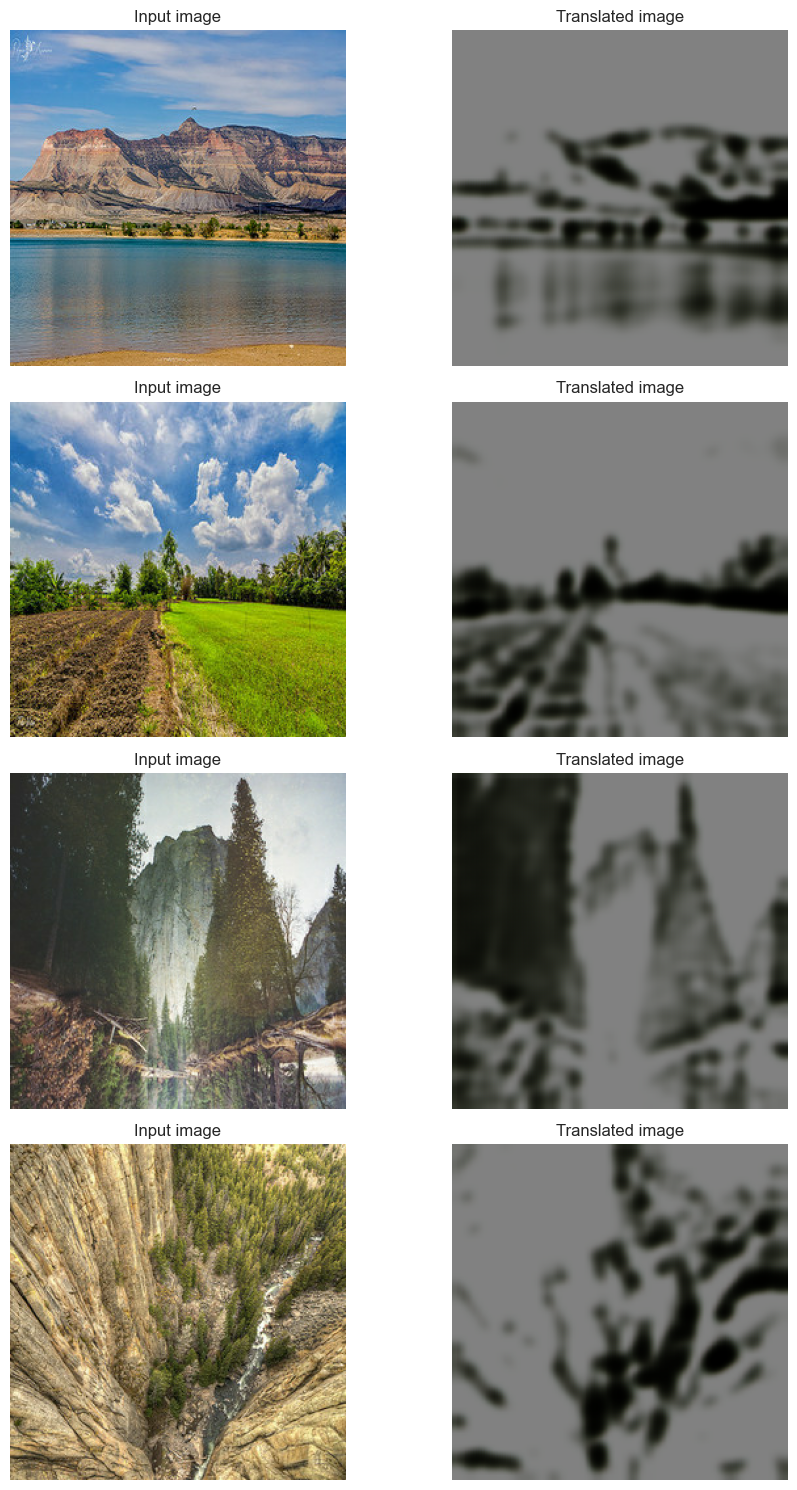

In [16]:
# Once the weights are loaded, we will take a few samples from the test data and check the model's performance.
cycle_gan_model.load_weights(checkpoint_filepath)
_, ax = plt.subplots(4, 2, figsize=(10, 15))
for i, (monet_img, photo_img) in enumerate(train_dataset.take(4)):
    prediction = cycle_gan_model.gen_G(photo_img, training=False)[0].numpy()
    prediction = (prediction * 127.5 + 127.5).astype(np.uint8)
    img = (photo_img[0] * 127.5 + 127.5).numpy().astype(np.uint8)

    ax[i, 0].imshow(img)
    ax[i, 1].imshow(prediction)
    ax[i, 0].set_title("Input image")
    ax[i, 0].set_title("Input image")
    ax[i, 1].set_title("Translated image")
    ax[i, 0].axis("off")
    ax[i, 1].axis("off")

    prediction = keras.utils.array_to_img(prediction)
    prediction.save(os.path.join(FIG_DIR, "predicted_img_{i}.png".format(i=i)))
plt.tight_layout()
plt.show()

## Kaggle Submission

In [19]:
# First, create a dataset without the repeat() used earlier to get exactly 7028 photos
def create_photo_dataset(photo_files, img_size=(256, 256), batch_size=1):
    def parse_and_resize(record):
        example = tf.io.parse_single_example(record, {
            'image': tf.io.FixedLenFeature([], tf.string)
        })
        image = tf.io.decode_jpeg(example['image'], channels=3)
        image = tf.image.resize(image, img_size)
        image = tf.cast(image, tf.float32) / 127.5 - 1.0  # Normalize to [-1, 1]
        return image

    photo_ds = (tf.data.TFRecordDataset(photo_files, num_parallel_reads=tf.data.AUTOTUNE)
                .map(parse_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

    return photo_ds

photo_dataset = create_photo_dataset(photo_files)

print(f"Starting generation of Monet-style images...")

# Generate Monet-style images for all 7028 photos and add to ZIP archive
zip_path = "./images.zip"
print(f"Creating ZIP archive: {zip_path}")
print(f"Starting generation of Monet-style images...")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for i, photo_batch in enumerate(photo_dataset):
        # Generate Monet-style image
        prediction = cycle_gan_model.gen_G(photo_batch, training=False)[0].numpy()
        prediction = (prediction * 127.5 + 127.5).astype(np.uint8)

        prediction_img = keras.utils.array_to_img(prediction)

        filename = f"monet_{i:05d}.jpg"

        # Save image to memory buffer as JPEG
        img_buffer = io.BytesIO()
        prediction_img.save(img_buffer, format='JPEG', quality=95)
        img_buffer.seek(0)

        # Write the image data directly to ZIP
        zipf.writestr(filename, img_buffer.getvalue())

        # Print progress every 500 images
        if (i + 1) % 500 == 0:
            print(f"Generated and zipped {i + 1} images...")

print(f"ZIP archive created with {i + 1} images")
print(f"Archive size: {zip_path.stat().st_size / (1024*1024):.1f} MB")
print(f"Final ZIP file: {zip_path}")


Starting generation of Monet-style images...
Creating ZIP archive: ./images.zip
Starting generation of Monet-style images...
Generated and zipped 500 images...
Generated and zipped 1000 images...
Generated and zipped 1500 images...
Generated and zipped 2000 images...
Generated and zipped 2500 images...
Generated and zipped 3000 images...
Generated and zipped 3500 images...
Generated and zipped 4000 images...
Generated and zipped 4500 images...
Generated and zipped 5000 images...
Generated and zipped 5500 images...
Generated and zipped 6000 images...
Generated and zipped 6500 images...
Generated and zipped 7000 images...
ZIP archive created with 7038 images


AttributeError: 'str' object has no attribute 'stat'

## Citations

1) This article is friendly and was useful in building understanding: https://jonathan-hui.medium.com/gan-cyclegan-6a50e7600d7
2) This Keras reference was my source for much of the code in the GAN model: https://keras.io/examples/generative/cyclegan/